In [ ]:
from google.colab import files

In [ ]:
upload = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [ ]:
import pandas as pd
df= pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Count and percentage of missing values **

In [ ]:
df.isnull().sum()
(df.isnull().mean() * 100).round(2)

,0
customerID,0.0
gender,0.0
SeniorCitizen,0.0
Partner,0.0
Dependents,0.0
tenure,0.0
PhoneService,0.0
MultipleLines,0.0
InternetService,0.0
OnlineSecurity,0.0


** To check Duplicate rows and duplicate customer IDs**

In [ ]:
df.duplicated().sum()
df['customerID'].duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['customerID'].duplicated().sum()

np.int64(0)

## Part 4: Data Cleaning Decisions

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| TotalCharges column has 11 blank/whitespace values instead of numbers | Convert to numeric, treat blanks as missing | pd.to_numeric(errors='coerce') | These blanks correspond to customers with tenure=0 (brand new customers who haven't been billed yet), so it is not random missingness |
| 11 rows have missing TotalCharges after conversion | Drop these rows | df.dropna(subset=['TotalCharges']) | Only 11 out of 7043 rows (~0.15%) - negligible data loss, and filling with 0 could mislead the model into thinking they are low spenders |

In [ ]:
df_clean = df.copy()

In [1]:
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

NameError: name 'pd' is not defined

In [ ]:
print("Missing TotalCharges after conversion:", df_clean['TotalCharges'].isnull().sum())

Missing TotalCharges after conversion: 11


In [ ]:
df_clean = df_clean.dropna(subset=['TotalCharges'])

In [ ]:
print("Shape after cleaning:", df_clean.shape)

Shape after cleaning: (7032, 21)


In [ ]:
print("Missing TotalCharges now:", df_clean['TotalCharges'].isnull().sum())
df_clean.dtypes

Missing TotalCharges now: 0


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


## part 5 -  Univariate EDA


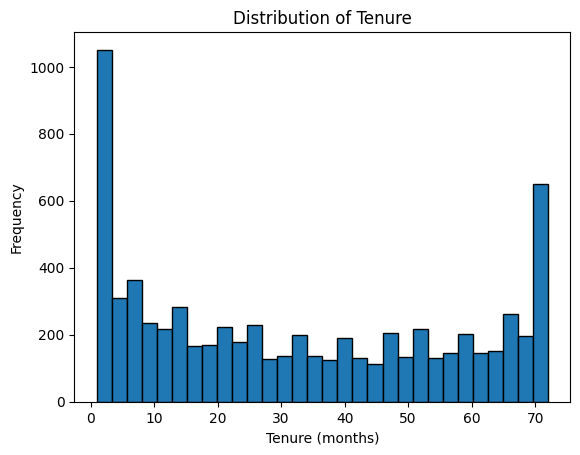

In [ ]:
df_clean['tenure'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (months)')
plt.show()

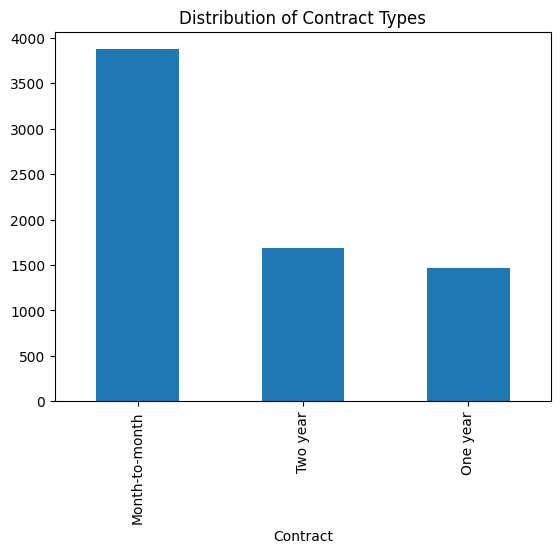

In [ ]:
df_clean['Contract'].value_counts().plot(kind='bar')
plt.title('Distribution of Contract Types')
plt.show()

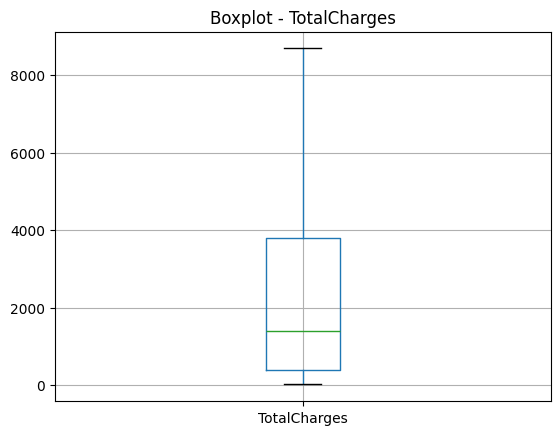

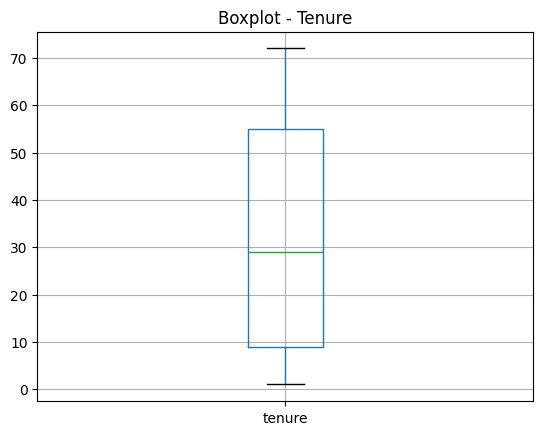

In [ ]:
df_clean.boxplot(column='TotalCharges')
plt.title('Boxplot - TotalCharges')
plt.show()

df_clean.boxplot(column='tenure')
plt.title('Boxplot - Tenure')
plt.show()

## Part 6 — Target Variable Analysis

In [ ]:
df_clean['Churn'].value_counts()
df_clean['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


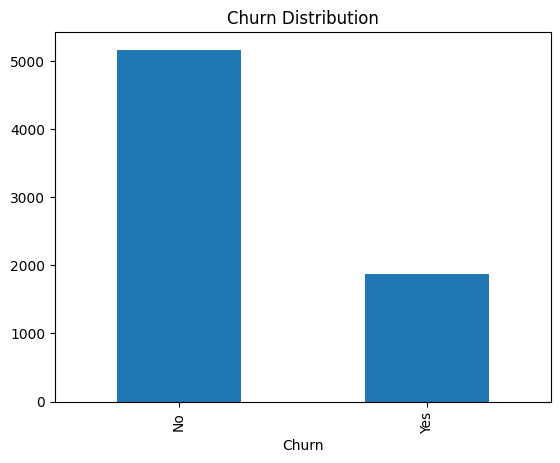

In [ ]:
df_clean['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.show()

 ## Part 7 — Bivariate Analysis: Features vs. Churn

In [ ]:
pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


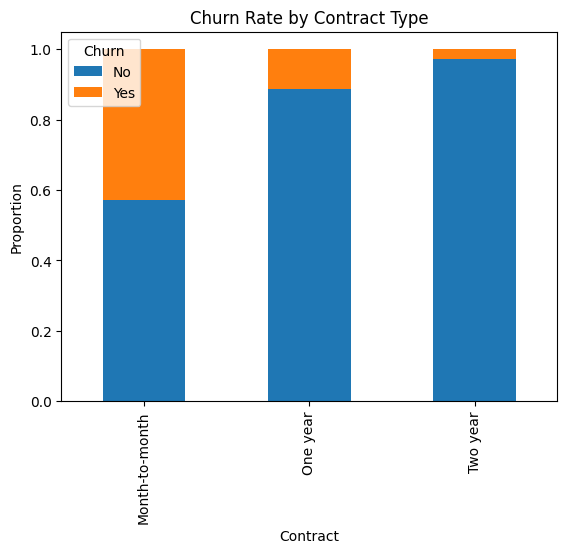

In [ ]:
pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Proportion')
plt.show()

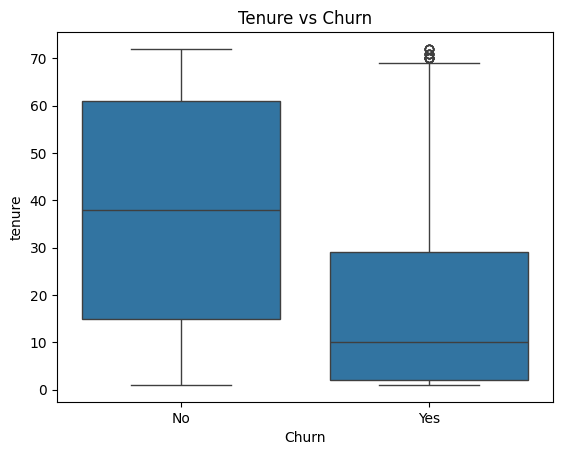

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df_clean)
plt.title('Tenure vs Churn')
plt.show()

 ## Part 8 — Correlation & Feature Relationships

In [ ]:
corr_matrix = df_clean.corr(numeric_only=True)
corr_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


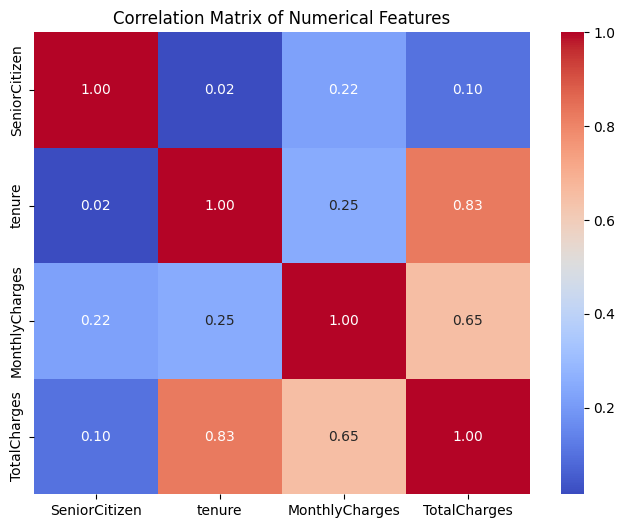

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

##Part 9 — Data Leakage Awareness

In [ ]:
df_clean.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [ ]:
for col in df_clean.columns:
    print(f"{col}: {df_clean[col].unique()[:5]}")

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 42.3  70.7 ]
TotalCharges: [  29.85 1889.5   108.15 1840.75  151.65]
Churn: ['No' 'Yes']


##Part 10 — ML-Readiness Checklist

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Unique per row, no predictive value (Part 9) |
| gender | Categorical | Feature | Keep | Categorical predictor, needs encoding before modeling |
| SeniorCitizen | Numerical (binary 0/1) | Feature | Keep | Already numeric, ready to use |
| Partner | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| Dependents | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| tenure | Numerical | Feature | Keep | Right-skewed distribution (Part 5); strongly related to churn — churned customers have much lower tenure (Part 7 boxplot) |
| PhoneService | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| MultipleLines | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| InternetService | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| OnlineSecurity | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| OnlineBackup | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| DeviceProtection | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| TechSupport | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| StreamingTV | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| StreamingMovies | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| Contract | Categorical | Feature | Keep | Very strong relationship with churn: 42.7% churn for month-to-month vs 11.3% for one-year vs 2.8% for two-year (Part 7) |
| PaperlessBilling | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| PaymentMethod | Categorical | Feature | Keep | Categorical predictor, needs encoding |
| MonthlyCharges | Numerical | Feature | Keep | May need scaling before modeling |
| TotalCharges | Numerical | Feature | Keep | Was object dtype with 11 blank values, cleaned in Part 4; correlated with tenure (Part 8), watch for redundancy |
| Churn | Categorical | Target | Keep | This is the variable being predicted; distribution is imbalanced ~73% No / ~27% Yes (Part 6) |

 ## Part 11 — Building the Clean Dataset

In [3]:
clean_df = df.copy()

clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df = clean_df.dropna(subset=['TotalCharges'])
clean_df = clean_df.drop(columns=['customerID'])

clean_df = clean_df.drop_duplicates()

print("Final shape:", clean_df.shape)

SyntaxError: invalid syntax (3291832794.py, line 4)

In [ ]:
clean_df.to_csv('clean_churn.csv', index=False)

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 
 17  

 ##Part 12 — Key Findings & Final Reflection

In [ ]:
Finding 1:
Observation: [kya dekha — 1 line]
Evidence: [numbers/chart jo isko support karte hain]
Interpretation: [iska matlab kya hai business ke liye]

SyntaxError: invalid character '—' (U+2014) (2590881244.py, line 2)